# Pathfinding Visualiser Survey Analysis

This notebook analyzes a within-subject pre/post survey about learning pathfinding algorithms with and without the visualiser.

## Research objective
- Compare the same respondents before and after the app experience on six repeated understanding items.
- Use preference and post-use evaluation items as supporting evidence.
- Keep the paired pre/post result as the primary basis for conclusions.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
from scipy.stats import kruskal, rankdata, wilcoxon

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

PRE_COLOR = "#4A90D9"
POST_COLOR = "#E8853D"
NEUTRAL_COLOR = "#9E9E9E"
POS_COLOR = "#2E8B57"
NEG_COLOR = "#C44E52"
TOOL_COLOR = "#2196F3"
TRAD_COLOR = "#FF9800"
NO_DIFF_COLOR = "#9E9E9E"

role_order = [
    "Year 1 undergraduate",
    "Year 2 undergraduate",
    "Year 3 undergraduate",
    "Year 4 / Final-year undergraduate",
    "Postgraduate",
    "University Lecturer",
    "Worker",
    "Self-learner (not currently studying CS)",
]

familiarity_order = [
    "Never heard of them",
    "Heard of them but not confident",
    "Used in class before",
]

visual_tool_freq_order = ["Never", "Rarely", "Sometimes", "Often"]

pref_order = [
    "Tool-supported learning (interactive visualiser + Insight Panel explanations)",
    "Traditional/theory-first learning (notes/lecture/textbook/pseudocode)",
    "No difference",
]

pref_short = {
    pref_order[0]: "Tool-supported",
    pref_order[1]: "Traditional",
    pref_order[2]: "No difference",
}

question_labels = {
    "q1": "Confidence in operation",
    "q2": "Logic and math rules",
    "q3": "Mental model",
    "q4": "Differentiation",
    "q5": "Key variables",
    "q6": "Explain to others",
}

new_cols = [
    "timestamp", "consent", "role", "familiarity", "visual_tool_freq",
    "pre_q1", "pre_q2", "pre_q3", "pre_q4", "pre_q5", "pre_q6",
    "post_q1", "post_q2", "post_q3", "post_q4", "post_q5", "post_q6",
    "pref_easier", "pref_beginner", "pref_quick",
    "tool_eval_needs", "tool_eval_without_instruction", "tool_eval_easy_to_use", "tool_eval_more_effective_than_theory",
]

pre_cols = [f"pre_q{i}" for i in range(1, 7)]
post_cols = [f"post_q{i}" for i in range(1, 7)]
pref_cols = ["pref_easier", "pref_beginner", "pref_quick"]
tool_eval_cols = [
    "tool_eval_needs",
    "tool_eval_without_instruction",
    "tool_eval_easy_to_use",
    "tool_eval_more_effective_than_theory",
]

all_likert_cols = pre_cols + post_cols + tool_eval_cols

paired_items = [f"Q{i}" for i in range(1, 7)]
derived_metric = "Composite (derived from mean Q1-Q6)"
report_label = "6 paired items + 1 derived composite"

def format_p(value):
    if pd.isna(value):
        return "NA"
    if value < 0.001:
        return "< .001"
    return f"{value:.3f}"


def significance_marker(value):
    if pd.isna(value):
        return ""
    if value < 0.001:
        return "***"
    if value < 0.01:
        return "**"
    if value < 0.05:
        return "*"
    return ""


def holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    adjusted_sorted = np.empty(len(p_values), dtype=float)
    for rank, idx in enumerate(order):
        adjusted_sorted[rank] = (len(p_values) - rank) * p_values[idx]
    adjusted_sorted = np.maximum.accumulate(adjusted_sorted)
    adjusted_sorted = np.clip(adjusted_sorted, 0, 1)
    adjusted = np.empty(len(p_values), dtype=float)
    adjusted[order] = adjusted_sorted
    return adjusted


def rank_biserial_from_paired_diff(diff_series):
    diff = pd.Series(diff_series).dropna()
    diff = diff[diff != 0]
    if diff.empty:
        return 0.0
    ranks = rankdata(np.abs(diff), method="average")
    signs = np.sign(diff.to_numpy())
    w_pos = ranks[signs > 0].sum()
    w_neg = ranks[signs < 0].sum()
    return float((w_pos - w_neg) / (w_pos + w_neg))


def paired_wilcoxon_summary(pre_series, post_series):
    paired = pd.DataFrame({"pre": pre_series, "post": post_series}).dropna()
    diff = paired["post"] - paired["pre"]
    nonzero = diff[diff != 0]
    result = {
        "n_pairs": int(len(paired)),
        "n_nonzero": int(len(nonzero)),
        "w": np.nan,
        "p_raw": np.nan,
        "rank_biserial": 0.0,
        "mean_delta": float(diff.mean()) if len(diff) else np.nan,
        "direction": "no change",
    }
    if len(paired) == 0:
        return result
    if len(nonzero) == 0:
        return result
    stat, p_value = wilcoxon(paired["post"], paired["pre"], alternative="two-sided")
    result["w"] = float(stat)
    result["p_raw"] = float(p_value)
    result["rank_biserial"] = rank_biserial_from_paired_diff(nonzero)
    if result["mean_delta"] > 0:
        result["direction"] = "increase"
    elif result["mean_delta"] < 0:
        result["direction"] = "decrease"
    return result


def bootstrap_paired_mean_ci(pre_series, post_series, n_boot=2000, random_state=42):
    paired = pd.DataFrame({"pre": pre_series, "post": post_series}).dropna()
    diffs = (paired["post"] - paired["pre"]).to_numpy(dtype=float)
    if len(diffs) == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(random_state)
    boot = rng.choice(diffs, size=(n_boot, len(diffs)), replace=True).mean(axis=1)
    return float(diffs.mean()), float(np.percentile(boot, 2.5)), float(np.percentile(boot, 97.5))


def bootstrap_mean_ci(series, n_boot=2000, random_state=42):
    values = pd.Series(series).dropna().to_numpy(dtype=float)
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(random_state)
    boot = rng.choice(values, size=(n_boot, len(values)), replace=True).mean(axis=1)
    return float(values.mean()), float(np.percentile(boot, 2.5)), float(np.percentile(boot, 97.5))


def split_multiselect(series):
    exploded = (
        pd.Series(series)
        .fillna("")
        .astype(str)
        .str.split(",")
        .explode()
        .str.strip()
    )
    exploded = exploded[exploded.ne("")]
    return exploded


## Analysis Scope

- `paired_items`: Q1-Q6 (true pre-post repeated questions)
- `derived_metric`: composite mean of Q1-Q6
- `report_label`: 6 paired items + 1 derived composite

Interpretation rule:
- Claims about learning change must be based on paired pre-post outputs.
- Post-use evaluation items are post-only supporting evidence.

In [2]:
preferred_csv_names = ["evaluating.csv"]
search_roots = []
for root in [
    Path.cwd(),
    Path.cwd().parent,
    Path("/Users/truongphuc/Desktop/collab"),
    Path.home() / "Desktop" / "collab",
]:
    if root.exists():
        resolved = root.resolve()
        if resolved not in search_roots:
            search_roots.append(resolved)

csv_candidates = []
for root in search_roots:
    for name in preferred_csv_names:
        candidate = root / name
        if candidate.exists():
            csv_candidates.append(candidate)

if not csv_candidates:
    for root in search_roots:
        csv_candidates.extend(sorted(root.glob("*.csv")))

csv_candidates = list(dict.fromkeys(path.resolve() for path in csv_candidates))

if not csv_candidates:
    try:
        from google.colab import files
        print("No CSV found in runtime. Upload a survey CSV to continue.")
        uploaded = files.upload()
        csv_candidates = [Path(name).resolve() for name in uploaded if name.lower().endswith(".csv")]
    except Exception:
        pass

assert csv_candidates, (
    f"No CSV file was found. Checked roots: {[str(root) for root in search_roots]}. "
    "If running on Colab/web, upload evaluating.csv first."
)

if len(csv_candidates) == 1:
    csv_path = csv_candidates[0]
else:
    survey_like = [
        path for path in csv_candidates
        if any(token in path.stem.lower() for token in ["evaluat", "pathfinding", "visualiser"])
    ]
    if survey_like:
        csv_path = max(survey_like, key=lambda path: path.stat().st_mtime)
    else:
        csv_path = max(csv_candidates, key=lambda path: path.stat().st_mtime)

df_raw = pd.read_csv(csv_path)
required_cols = len(new_cols)
if df_raw.shape[1] < required_cols:
    raise AssertionError(
        f"Expected at least {required_cols} columns for mapping, found {df_raw.shape[1]}"
    )
if df_raw.shape[1] > required_cols:
    warnings.warn(
        f"Detected {df_raw.shape[1]} columns; expected {required_cols}. "
        "Extra columns will be ignored by taking the first 25 columns."
    )

df = df_raw.iloc[:, :required_cols].copy()
df.columns = new_cols

df["timestamp"] = pd.to_datetime(df["timestamp"], dayfirst=True, errors="raise")
for col in all_likert_cols:
    df[col] = pd.to_numeric(df[col], errors="raise")

df = df.drop(columns=["consent"])
assert df.shape[1] == 23, f"Expected 23 columns after dropping consent, found {df.shape[1]}"

df["role"] = pd.Categorical(df["role"], categories=role_order, ordered=True)
df["familiarity"] = pd.Categorical(df["familiarity"], categories=familiarity_order, ordered=True)
df["visual_tool_freq"] = pd.Categorical(df["visual_tool_freq"], categories=visual_tool_freq_order, ordered=True)
for col in pref_cols:
    df[col] = pd.Categorical(df[col], categories=pref_order, ordered=True)

print(f"Runtime working directory: {Path.cwd()}")
print(f"Search roots checked: {[str(root) for root in search_roots]}")
print(f"Selected CSV: {csv_path}")
print(f"Raw shape before mapping: {df_raw.shape}")
print(f"Rows x columns after cleaning: {df.shape}")
print(f"N respondents: {len(df)}")
print(f"Analysis scope: {report_label}")
print(f"Earliest timestamp: {df['timestamp'].min()}")
print(f"Latest timestamp:   {df['timestamp'].max()}")

Runtime working directory: /Users/truongphuc/Desktop/imgg/pathfindingredesign/result+analyst
Search roots checked: ['/Users/truongphuc/Desktop/imgg/pathfindingredesign/result+analyst', '/Users/truongphuc/Desktop/imgg/pathfindingredesign', '/Users/truongphuc/Desktop/collab']
Selected CSV: /Users/truongphuc/Desktop/imgg/pathfindingredesign/result+analyst/evaluating.csv
Raw shape before mapping: (38, 24)
Rows x columns after cleaning: (38, 23)
N respondents: 38
Analysis scope: 6 paired items + 1 derived composite
Earliest timestamp: 2026-03-02 10:32:04
Latest timestamp:   2026-03-12 17:45:30


In [3]:
missing_total = int(df.isna().sum().sum())
out_of_range = {col: sorted(df.loc[~df[col].between(1, 5), col].unique().tolist()) for col in all_likert_cols if not df[col].between(1, 5).all()}
assert not out_of_range, f"Likert values outside 1-5 found: {out_of_range}"

duplicate_timestamps = int(df["timestamp"].duplicated().sum())
df["straightline_full12"] = (df[pre_cols + post_cols].nunique(axis=1) == 1)
df["straightline_by_section"] = (
    (df[pre_cols].nunique(axis=1) == 1) &
    (df[post_cols].nunique(axis=1) == 1)
)

df["pre_composite"] = df[pre_cols].mean(axis=1)
df["post_composite"] = df[post_cols].mean(axis=1)
df["improvement"] = df["post_composite"] - df["pre_composite"]

n_improved = int((df["improvement"] > 0).sum())
n_same = int((df["improvement"] == 0).sum())
n_declined = int((df["improvement"] < 0).sum())

qc_summary = pd.DataFrame(
    {
        "metric": [
            "Respondents",
            "Missing cells",
            "Duplicate timestamps",
            "Full straightliners across 12 repeated items",
            "Section-wise straightliners (pre constant, post constant)",
            "Composite improved",
            "Composite unchanged",
            "Composite declined",
        ],
        "value": [
            len(df),
            missing_total,
            duplicate_timestamps,
            int(df["straightline_full12"].sum()),
            int(df["straightline_by_section"].sum()),
            n_improved,
            n_same,
            n_declined,
        ],
    }
)

display(qc_summary)
print("QC summary ready for reuse in the conclusion cell.")


,metric,value
0,Respondents,38
1,Missing cells,0
2,Duplicate timestamps,0
3,Full straightliners across 12 repeated items,8
4,"Section-wise straightliners (pre constant, pos...",9
5,Composite improved,13
6,Composite unchanged,13
7,Composite declined,12


QC summary ready for reuse in the conclusion cell.


## Demographics


In [4]:
demographic_specs = {
    "role": role_order,
    "familiarity": familiarity_order,
    "visual_tool_freq": visual_tool_freq_order,
}

demo_frames = []
for col, order in demographic_specs.items():
    counts = df[col].value_counts(dropna=False).reindex(order, fill_value=0)
    frame = pd.DataFrame({
        "category": col,
        "level": counts.index.astype(str),
        "count": counts.values,
    })
    frame["percent"] = frame["count"] / len(df) * 100
    demo_frames.append(frame)

demographics_table = pd.concat(demo_frames, ignore_index=True)
display(demographics_table.style.format({"percent": "{:.1f}%"}))


,category,level,count,percent
0,role,Year 1 undergraduate,6,15.8%
1,role,Year 2 undergraduate,7,18.4%
2,role,Year 3 undergraduate,8,21.1%
3,role,Year 4 / Final-year undergraduate,10,26.3%
4,role,Postgraduate,4,10.5%
5,role,University Lecturer,1,2.6%
6,role,Worker,1,2.6%
7,role,Self-learner (not currently studying CS),1,2.6%
8,familiarity,Never heard of them,17,44.7%
9,familiarity,Heard of them but not confident,13,34.2%


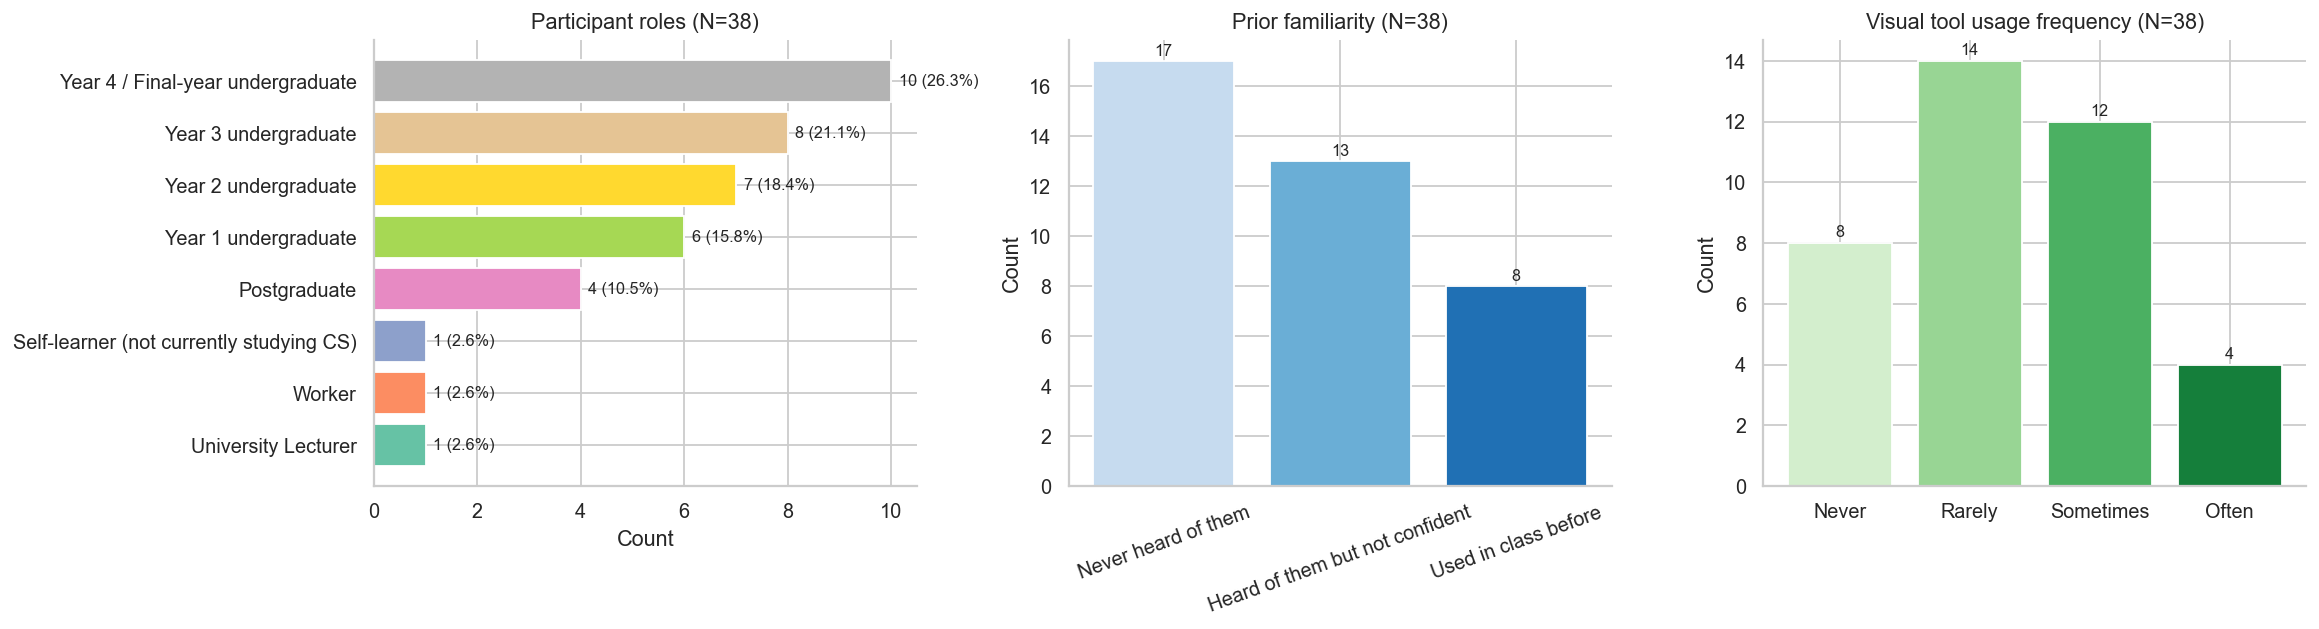

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

role_counts = df["role"].value_counts().reindex(role_order).dropna()
role_counts = role_counts[role_counts > 0].sort_values()
axes[0].barh(role_counts.index.astype(str), role_counts.values, color=sns.color_palette("Set2", n_colors=len(role_counts)))
axes[0].set_title(f"Participant roles (N={len(df)})")
axes[0].set_xlabel("Count")
for i, value in enumerate(role_counts.values):
    axes[0].text(value + 0.15, i, f"{value} ({value / len(df) * 100:.1f}%)", va="center", fontsize=9)

fam_counts = df["familiarity"].value_counts().reindex(familiarity_order)
axes[1].bar(fam_counts.index.astype(str), fam_counts.values, color=sns.color_palette("Blues", n_colors=len(fam_counts)))
axes[1].set_title(f"Prior familiarity (N={len(df)})")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=20)
for i, value in enumerate(fam_counts.values):
    axes[1].text(i, value + 0.2, str(int(value)), ha="center", fontsize=9)

freq_counts = df["visual_tool_freq"].value_counts().reindex(visual_tool_freq_order)
axes[2].bar(freq_counts.index.astype(str), freq_counts.values, color=sns.color_palette("Greens", n_colors=len(freq_counts)))
axes[2].set_title(f"Visual tool usage frequency (N={len(df)})")
axes[2].set_ylabel("Count")
for i, value in enumerate(freq_counts.values):
    axes[2].text(i, value + 0.2, str(int(value)), ha="center", fontsize=9)

plt.tight_layout()
plt.show()


## Paired Pre/Post Analysis

The six repeated items are the primary evidence for the research question because the same respondents rated themselves before and after using the app.


In [6]:
paired_rows = []
for idx, (pre_col, post_col) in enumerate(zip(pre_cols, post_cols), start=1):
    diff = df[post_col] - df[pre_col]
    paired_rows.append({
        "item_type": "paired",
        "Item": f"Q{idx}",
        "Label": question_labels[f"q{idx}"],
        "Pre mean": df[pre_col].mean(),
        "Pre median": df[pre_col].median(),
        "Post mean": df[post_col].mean(),
        "Post median": df[post_col].median(),
        "Mean delta": diff.mean(),
        "% improved": (diff.gt(0).mean() * 100),
        "% same": (diff.eq(0).mean() * 100),
        "% declined": (diff.lt(0).mean() * 100),
    })

comp_diff = df["post_composite"] - df["pre_composite"]
paired_rows.append({
    "item_type": "derived",
    "Item": "Composite",
    "Label": "Mean of Q1-Q6",
    "Pre mean": df["pre_composite"].mean(),
    "Pre median": df["pre_composite"].median(),
    "Post mean": df["post_composite"].mean(),
    "Post median": df["post_composite"].median(),
    "Mean delta": comp_diff.mean(),
    "% improved": (comp_diff.gt(0).mean() * 100),
    "% same": (comp_diff.eq(0).mean() * 100),
    "% declined": (comp_diff.lt(0).mean() * 100),
})

paired_descriptives = pd.DataFrame(paired_rows)
display(
    paired_descriptives[[
        "item_type", "Item", "Label", "Pre mean", "Pre median", "Post mean", "Post median",
        "Mean delta", "% improved", "% same", "% declined"
    ]].style.format({
        "Pre mean": "{:.2f}",
        "Pre median": "{:.2f}",
        "Post mean": "{:.2f}",
        "Post median": "{:.2f}",
        "Mean delta": "{:+.2f}",
        "% improved": "{:.1f}%",
        "% same": "{:.1f}%",
        "% declined": "{:.1f}%",
    })
)

,item_type,Item,Label,Pre mean,Pre median,Post mean,Post median,Mean delta,% improved,% same,% declined
0,paired,Q1,Confidence in operation,3.11,3.00,3.39,3.00,+0.29,34.2%,50.0%,15.8%
1,paired,Q2,Logic and math rules,3.08,3.00,3.00,3.00,-0.08,21.1%,52.6%,26.3%
2,paired,Q3,Mental model,3.24,3.00,3.47,3.50,+0.24,36.8%,39.5%,23.7%
3,paired,Q4,Differentiation,3.11,3.00,3.26,3.00,+0.16,23.7%,52.6%,23.7%
4,paired,Q5,Key variables,3.21,3.00,3.26,3.00,+0.05,28.9%,39.5%,31.6%
5,paired,Q6,Explain to others,3.13,3.00,3.39,3.00,+0.26,39.5%,39.5%,21.1%
6,derived,Composite,Mean of Q1-Q6,3.14,3.00,3.30,3.42,+0.15,34.2%,34.2%,31.6%


In [7]:
item_results = []
for idx, (pre_col, post_col) in enumerate(zip(pre_cols, post_cols), start=1):
    summary = paired_wilcoxon_summary(df[pre_col], df[post_col])
    item_results.append({
        "item_type": "paired",
        "Item": f"Q{idx}",
        "Label": question_labels[f"q{idx}"],
        **summary,
    })

item_results_df = pd.DataFrame(item_results)
item_results_df["p_holm"] = holm_adjust(item_results_df["p_raw"].to_numpy())
composite_result = paired_wilcoxon_summary(df["pre_composite"], df["post_composite"])

wilcoxon_table = pd.concat(
    [
        pd.DataFrame([{
            "item_type": "derived",
            "Item": "Composite",
            "Label": "Mean of Q1-Q6",
            **composite_result,
            "p_holm": np.nan,
        }]),
        item_results_df,
    ],
    ignore_index=True,
)

item_display = item_results_df[["Item", "Label", "p_raw", "p_holm"]].copy()
item_display = item_display.rename(columns={
    "Label": "Question focus",
    "p_raw": "Raw p",
    "p_holm": "Adjusted p for judgement",
})

composite_display = pd.DataFrame([
    {
        "Item": "Composite",
        "Question focus": "Mean of Q1-Q6",
        "Raw p": composite_result["p_raw"],
        "Adjusted p for judgement": np.nan,
    }
])

table4_display = pd.concat([composite_display, item_display], ignore_index=True)

display(
    table4_display[["Item", "Question focus", "Raw p", "Adjusted p for judgement"]].style.format({
        "Raw p": lambda v: format_p(v),
        "Adjusted p for judgement": lambda v: "—" if pd.isna(v) else format_p(v),
    })
)

print("Size and direction of change are reported in Table 3. Raw p values are shown for transparency. Adjusted p values are used for item-level judgement; the composite is judged using its raw p value.")



,Item,Question focus,Raw p,Adjusted p for judgement
0,Composite,Mean of Q1-Q6,0.389,—
1,Q1,Confidence in operation,0.135,0.808
2,Q2,Logic and math rules,0.657,1.000
3,Q3,Mental model,0.239,1.000
4,Q4,Differentiation,0.305,1.000
5,Q5,Key variables,0.827,1.000
6,Q6,Explain to others,0.287,1.000


Size and direction of change are reported in Table 3. Raw p values are shown for transparency. Adjusted p values are used for item-level judgement; the composite is judged using its raw p value.


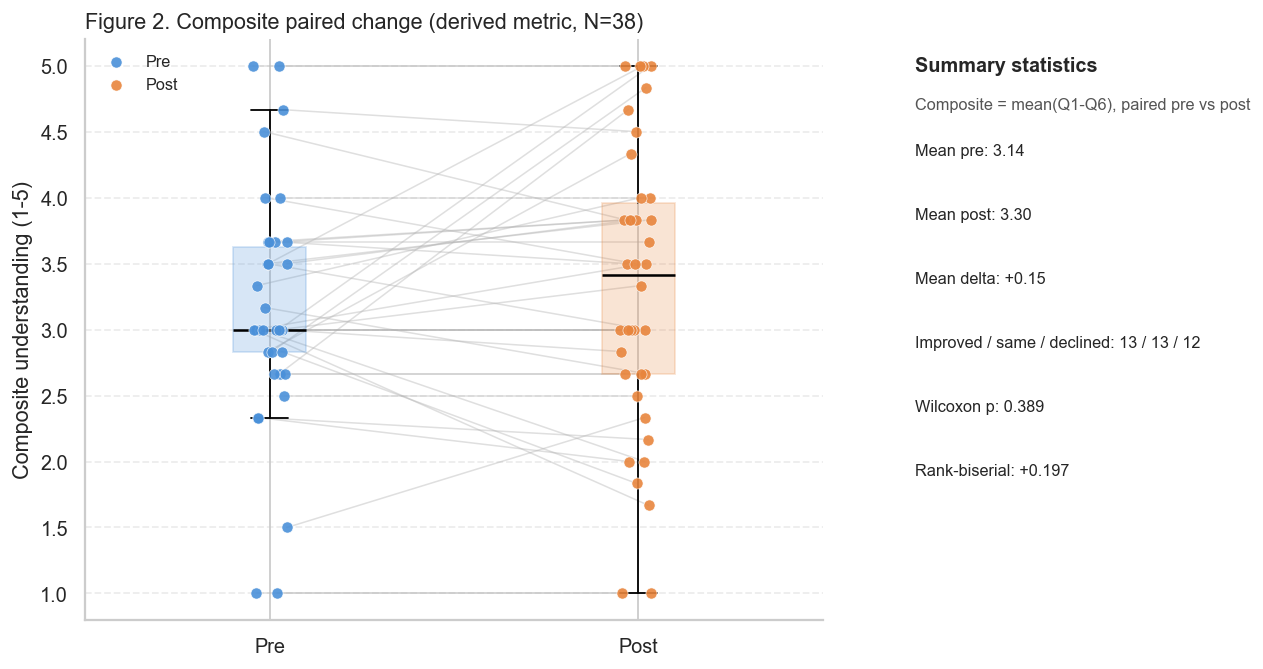

,Metric,Mean pre,Mean post,Mean delta,Improved / same / declined,Wilcoxon p,Rank-biserial
0,Composite (derived),3.14,3.30,+0.15,13 / 13 / 12,0.389,+0.197


In [8]:
COMPOSITE_STYLE = {
    "figsize": (11.5, 5.8),
    "width_ratios": (3.3, 1.5),
    "wspace": 0.16,
    "jitter": 0.05,
    "jitter_seed": 42,
    "line_color": "#B3B3B3",
    "line_alpha": 0.42,
    "line_width": 0.85,
    "point_size": 38,
    "point_alpha": 0.9,
    "box_width": 0.20,
    "y_limits": (0.8, 5.2),
    "title_size": 12,
    "side_title_size": 11,
    "side_text_size": 9,
}

def build_composite_plot_payload(df, composite_result, n_improved, n_same, n_declined):
    pre_values = df["pre_composite"].to_numpy(dtype=float)
    post_values = df["post_composite"].to_numpy(dtype=float)
    delta_values = post_values - pre_values
    payload = {
        "pre_values": pre_values,
        "post_values": post_values,
        "delta_values": delta_values,
        "mean_pre": float(df["pre_composite"].mean()),
        "mean_post": float(df["post_composite"].mean()),
        "mean_delta": float(df["improvement"].mean()),
        "n_improved": int(n_improved),
        "n_same": int(n_same),
        "n_declined": int(n_declined),
        "p_raw": float(composite_result["p_raw"]),
        "rank_biserial": float(composite_result["rank_biserial"]),
        "n": int(len(df)),
    }
    payload["summary_lines"] = [
        f"Mean pre: {payload['mean_pre']:.2f}",
        f"Mean post: {payload['mean_post']:.2f}",
        f"Mean delta: {payload['mean_delta']:+.2f}",
        f"Improved / same / declined: {payload['n_improved']} / {payload['n_same']} / {payload['n_declined']}",
        f"Wilcoxon p: {format_p(payload['p_raw'])}",
        f"Rank-biserial: {payload['rank_biserial']:+.3f}",
    ]
    return payload

def plot_composite_main(ax, payload, style):
    rng = np.random.default_rng(style["jitter_seed"])
    n = payload["n"]
    x_pre = np.zeros(n) + rng.uniform(-style["jitter"], style["jitter"], size=n)
    x_post = np.ones(n) + rng.uniform(-style["jitter"], style["jitter"], size=n)

    for x0, x1, y0, y1 in zip(x_pre, x_post, payload["pre_values"], payload["post_values"]):
        ax.plot(
            [x0, x1],
            [y0, y1],
            color=style["line_color"],
            alpha=style["line_alpha"],
            linewidth=style["line_width"],
            zorder=1,
        )

    ax.scatter(
        x_pre,
        payload["pre_values"],
        color=PRE_COLOR,
        s=style["point_size"],
        alpha=style["point_alpha"],
        edgecolor="white",
        linewidth=0.35,
        label="Pre",
        zorder=3,
    )
    ax.scatter(
        x_post,
        payload["post_values"],
        color=POST_COLOR,
        s=style["point_size"],
        alpha=style["point_alpha"],
        edgecolor="white",
        linewidth=0.35,
        label="Post",
        zorder=3,
    )

    box = ax.boxplot(
        [payload["pre_values"], payload["post_values"]],
        positions=[0, 1],
        widths=style["box_width"],
        patch_artist=True,
        showfliers=False,
        medianprops={"color": "black", "linewidth": 1.4},
    )
    for patch, color in zip(box["boxes"], [PRE_COLOR, POST_COLOR]):
        patch.set_facecolor(color)
        patch.set_alpha(0.22)
        patch.set_edgecolor(color)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Pre", "Post"])
    ax.set_ylabel("Composite understanding (1-5)")
    ax.set_ylim(*style["y_limits"])
    ax.set_title(
        f"Figure 2. Composite paired change (derived metric, N={payload['n']})",
        loc="left",
        fontsize=style["title_size"],
    )
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)
    ax.legend(loc="upper left", frameon=False, fontsize=9)

def plot_composite_side(ax, payload, style):
    ax.axis("off")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.text(
        0.02,
        0.97,
        "Summary statistics",
        ha="left",
        va="top",
        fontsize=style["side_title_size"],
        weight="bold",
    )
    ax.text(
        0.02,
        0.90,
        "Composite = mean(Q1-Q6), paired pre vs post",
        ha="left",
        va="top",
        fontsize=style["side_text_size"],
        color="#555555",
    )

    y = 0.82
    for line in payload["summary_lines"]:
        ax.text(0.02, y, line, ha="left", va="top", fontsize=style["side_text_size"])
        y -= 0.11

def render_composite_figure(payload, style, n):
    fig = plt.figure(figsize=style["figsize"])
    gs = fig.add_gridspec(1, 2, width_ratios=style["width_ratios"], wspace=style["wspace"])
    ax_main = fig.add_subplot(gs[0, 0])
    ax_side = fig.add_subplot(gs[0, 1])
    plot_composite_main(ax_main, payload, style)
    plot_composite_side(ax_side, payload, style)
    return fig

composite_payload = build_composite_plot_payload(df, composite_result, n_improved, n_same, n_declined)
fig = render_composite_figure(composite_payload, COMPOSITE_STYLE, len(df))
plt.tight_layout()
plt.show()

composite_summary_table = pd.DataFrame(
    [
        {
            "Metric": "Composite (derived)",
            "Mean pre": f"{composite_payload['mean_pre']:.2f}",
            "Mean post": f"{composite_payload['mean_post']:.2f}",
            "Mean delta": f"{composite_payload['mean_delta']:+.2f}",
            "Improved / same / declined": f"{composite_payload['n_improved']} / {composite_payload['n_same']} / {composite_payload['n_declined']}",
            "Wilcoxon p": format_p(composite_payload["p_raw"]),
            "Rank-biserial": f"{composite_payload['rank_biserial']:+.3f}",
        }
    ]
)
display(composite_summary_table)


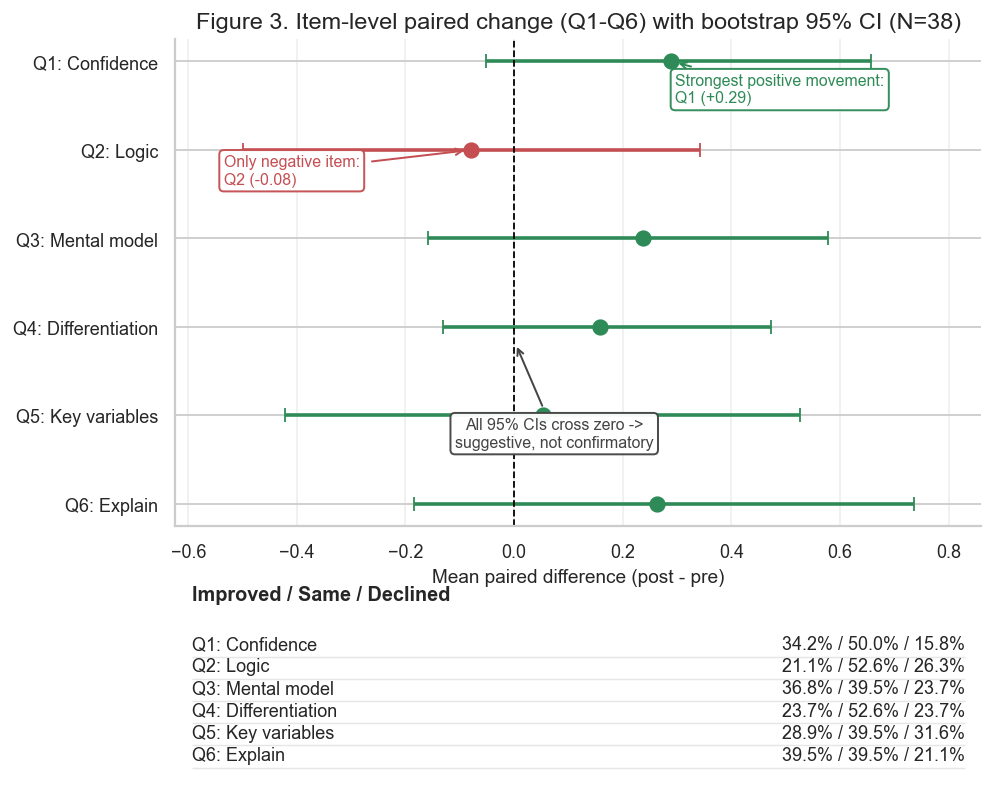

In [9]:
def build_forest_df(pre_cols, post_cols, question_labels, item_results_df):
    short_labels = {
        "q1": "Q1: Confidence",
        "q2": "Q2: Logic",
        "q3": "Q3: Mental model",
        "q4": "Q4: Differentiation",
        "q5": "Q5: Key variables",
        "q6": "Q6: Explain",
    }

    rows = []
    for idx, (pre_col, post_col) in enumerate(zip(pre_cols, post_cols), start=1):
        mean_diff, ci_low, ci_high = bootstrap_paired_mean_ci(
            df[pre_col], df[post_col], n_boot=2000, random_state=42 + idx
        )
        diff = df[post_col] - df[pre_col]
        holm_p = float(item_results_df.loc[item_results_df["Item"] == f"Q{idx}", "p_holm"].iloc[0])

        rows.append({
            "Item": f"Q{idx}",
            "Label": question_labels[f"q{idx}"],
            "display_label": short_labels[f"q{idx}"],
            "mean_diff": float(mean_diff),
            "ci_low": float(ci_low),
            "ci_high": float(ci_high),
            "pct_improved": float(diff.gt(0).mean() * 100),
            "pct_same": float(diff.eq(0).mean() * 100),
            "pct_declined": float(diff.lt(0).mean() * 100),
            "p_holm": holm_p,
            "sig_marker": significance_marker(holm_p) if holm_p < 0.05 else "",
            "color": POS_COLOR if mean_diff >= 0 else NEG_COLOR,
        })

    forest_df = pd.DataFrame(rows)
    forest_df["pct_triplet"] = forest_df.apply(
        lambda row: f"{row['pct_improved']:.1f}% / {row['pct_same']:.1f}% / {row['pct_declined']:.1f}%",
        axis=1,
    )
    return forest_df

FIG3_POSTER_STYLE = {
    "figsize": (8.0, 7.4),
    "height_ratios": (3.2, 1.35),
    "hspace": 0.14,
    "title_size": 13,
    "axis_label_size": 10.5,
    "tick_label_size": 10,
    "notes_header_size": 11,
    "notes_legend_size": 8.5,
    "notes_text_size": 10,
    "sig_marker_size": 11,
    "callout_size": 8.8,
}


def add_forest_callouts(ax, forest_df):
    item_to_y = {row["Item"]: idx for idx, row in enumerate(forest_df.to_dict("records"))}
    item_to_row = {row["Item"]: row for row in forest_df.to_dict("records")}

    callouts = [
        {
            "item": "Q1",
            "text": "Strongest positive movement:\nQ1 (+0.29)",
            "xytext": (0.62, 0.93),
            "ha": "left",
            "va": "top",
            "color": POS_COLOR,
        },
        {
            "item": "Q2",
            "text": "Only negative item:\nQ2 (-0.08)",
            "xytext": (0.06, 0.73),
            "ha": "left",
            "va": "center",
            "color": NEG_COLOR,
        },
        {
            "item": None,
            "text": "All 95% CIs cross zero ->\nsuggestive, not confirmatory",
            "xy": (0.0, 3.15),
            "xytext": (0.47, 0.19),
            "ha": "center",
            "va": "center",
            "color": "#444444",
        },
    ]

    for callout in callouts:
        if callout["item"] is not None:
            row = item_to_row[callout["item"]]
            xy = (row["mean_diff"], item_to_y[callout["item"]])
        else:
            xy = callout["xy"]

        ax.annotate(
            callout["text"],
            xy=xy,
            xycoords="data",
            xytext=callout["xytext"],
            textcoords="axes fraction",
            ha=callout["ha"],
            va=callout["va"],
            fontsize=FIG3_POSTER_STYLE["callout_size"],
            color=callout["color"],
            bbox={
                "boxstyle": "round,pad=0.28",
                "facecolor": "white",
                "edgecolor": callout["color"],
                "linewidth": 1.1,
                "alpha": 0.96,
            },
            arrowprops={
                "arrowstyle": "->",
                "color": callout["color"],
                "linewidth": 1.1,
                "shrinkA": 4,
                "shrinkB": 4,
            },
            annotation_clip=False,
            zorder=5,
        )


def plot_forest_main(ax, forest_df, n):
    y_positions = np.arange(len(forest_df))

    x_min = min(forest_df["ci_low"].min(), -0.05)
    x_max = max(forest_df["ci_high"].max(), 0.05)
    x_span = x_max - x_min
    x_pad = max(0.10 * x_span, 0.07)

    for y, row in zip(y_positions, forest_df.to_dict("records")):
        ax.errorbar(
            row["mean_diff"],
            y,
            xerr=[[row["mean_diff"] - row["ci_low"]], [row["ci_high"] - row["mean_diff"]]],
            fmt="o",
            color=row["color"],
            ecolor=row["color"],
            elinewidth=2,
            capsize=4,
            markersize=8,
        )

        if row["sig_marker"]:
            sig_offset = max(0.02 * x_span, 0.02)
            if row["mean_diff"] >= 0:
                ax.text(row["ci_high"] + sig_offset, y, row["sig_marker"], va="center", ha="left", fontsize=FIG3_POSTER_STYLE["sig_marker_size"])
            else:
                ax.text(row["ci_low"] - sig_offset, y, row["sig_marker"], va="center", ha="right", fontsize=FIG3_POSTER_STYLE["sig_marker_size"])

    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(forest_df["display_label"], fontsize=FIG3_POSTER_STYLE["tick_label_size"])
    ax.invert_yaxis()
    ax.tick_params(axis="x", labelsize=FIG3_POSTER_STYLE["tick_label_size"])
    ax.set_xlabel("Mean paired difference (post - pre)", fontsize=FIG3_POSTER_STYLE["axis_label_size"])
    ax.set_title(
        f"Figure 3. Item-level paired change (Q1-Q6) with bootstrap 95% CI (N={n})",
        fontsize=FIG3_POSTER_STYLE["title_size"],
    )
    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.grid(axis="x", alpha=0.3)
    add_forest_callouts(ax, forest_df)


def plot_forest_notes(ax, forest_df):
    ax.axis("off")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.text(0.02, 0.95, "Improved / Same / Declined", fontsize=FIG3_POSTER_STYLE["notes_header_size"], weight="bold", va="top")

    y_positions = np.linspace(0.66, 0.12, len(forest_df))
    for y, row in zip(y_positions, forest_df.to_dict("records")):
        ax.text(0.02, y, row["display_label"], ha="left", va="center", fontsize=FIG3_POSTER_STYLE["notes_text_size"])
        ax.text(0.98, y, row["pct_triplet"], ha="right", va="center", fontsize=FIG3_POSTER_STYLE["notes_text_size"])
        ax.hlines(y - 0.06, 0.02, 0.98, colors="#E6E6E6", linewidth=0.8)


forest_df = build_forest_df(pre_cols, post_cols, question_labels, item_results_df)

fig = plt.figure(figsize=FIG3_POSTER_STYLE["figsize"])
gs = fig.add_gridspec(2, 1, height_ratios=FIG3_POSTER_STYLE["height_ratios"], hspace=FIG3_POSTER_STYLE["hspace"])
ax_main = fig.add_subplot(gs[0, 0])
ax_notes = fig.add_subplot(gs[1, 0])

plot_forest_main(ax_main, forest_df, len(df))
plot_forest_notes(ax_notes, forest_df)

plt.tight_layout()
plt.show()


## Distribution View For Paired Items

This chart focuses on response distribution (not just means) for the 6 paired pre/post items.

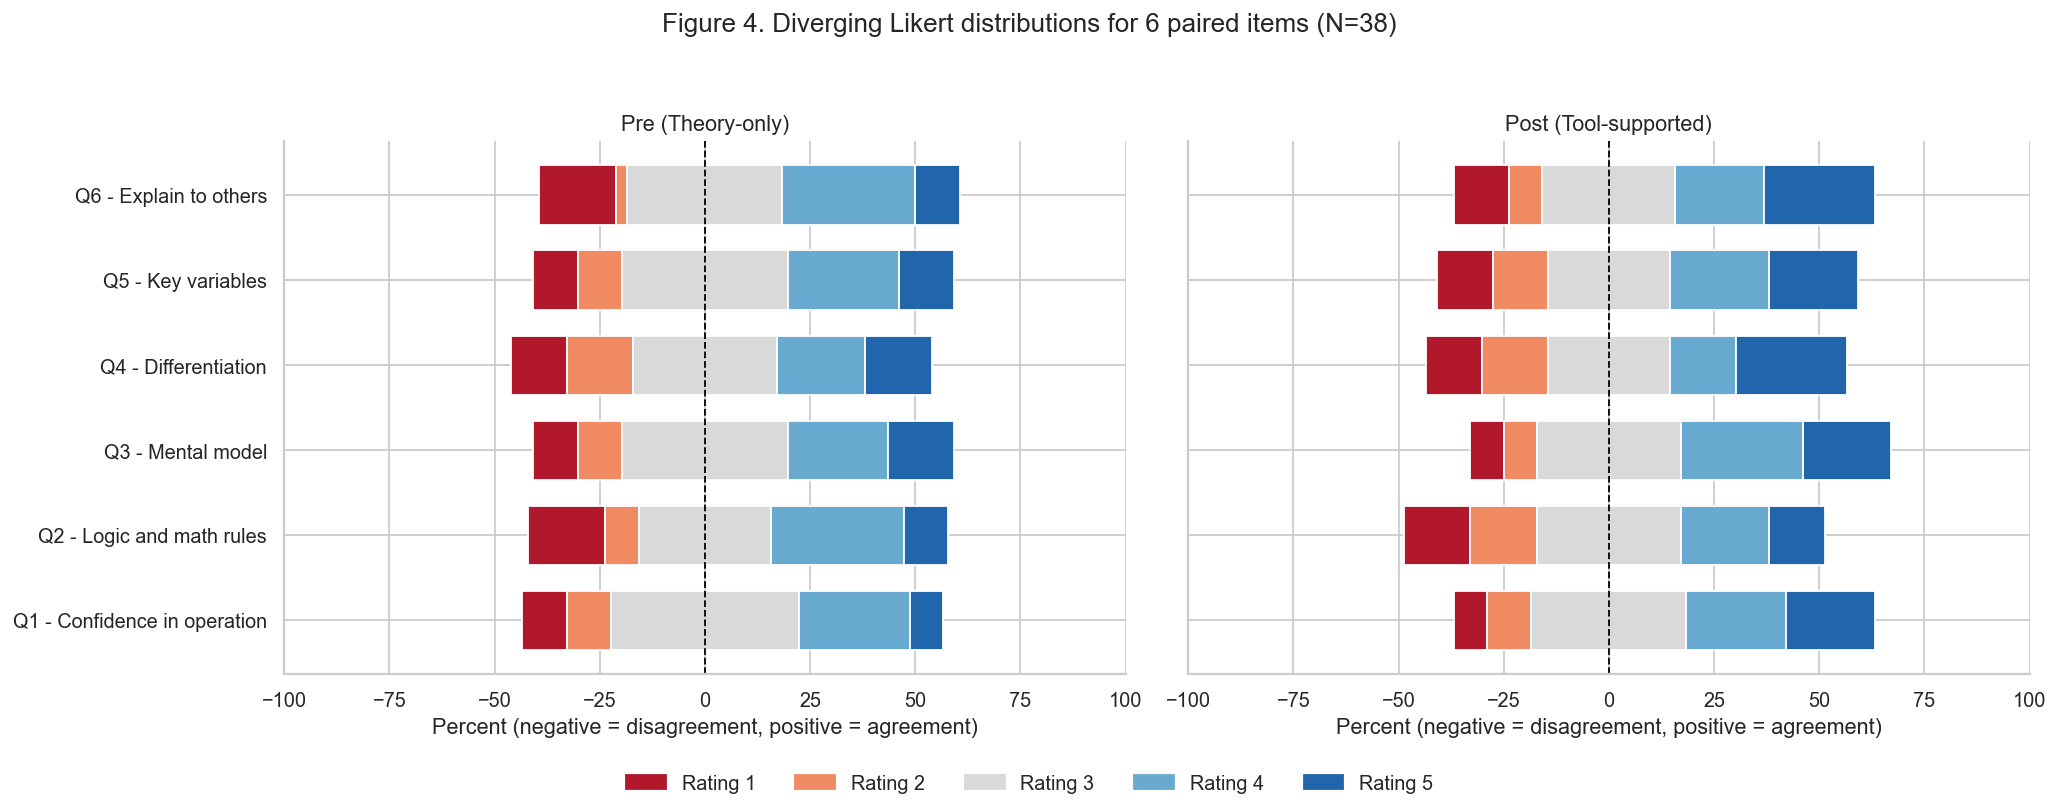

In [10]:
likert_scale = [1, 2, 3, 4, 5]
likert_colors = {
    1: "#B2182B",
    2: "#EF8A62",
    3: "#D9D9D9",
    4: "#67A9CF",
    5: "#2166AC",
}

short_q_labels = [question_labels[f"q{i}"] for i in range(1, 7)]

def likert_pct(frame, cols):
    rows = []
    for idx, col in enumerate(cols, start=1):
        pct = frame[col].value_counts(normalize=True).reindex(likert_scale, fill_value=0) * 100
        rows.append({"Item": f"Q{idx}", "Label": question_labels[f"q{idx}"], **{f"r{k}": pct[k] for k in likert_scale}})
    return pd.DataFrame(rows)

pre_dist = likert_pct(df, pre_cols)
post_dist = likert_pct(df, post_cols)


def draw_diverging(ax, dist_df, title):
    y = np.arange(len(dist_df))
    for i, row in dist_df.iterrows():
        p1, p2, p3, p4, p5 = row["r1"], row["r2"], row["r3"], row["r4"], row["r5"]
        left_1 = -(p1 + p2 + p3 / 2)
        left_2 = -(p2 + p3 / 2)
        left_3 = -(p3 / 2)
        left_4 = p3 / 2
        left_5 = p3 / 2 + p4

        ax.barh(i, p1, left=left_1, color=likert_colors[1], edgecolor="white", height=0.7)
        ax.barh(i, p2, left=left_2, color=likert_colors[2], edgecolor="white", height=0.7)
        ax.barh(i, p3, left=left_3, color=likert_colors[3], edgecolor="white", height=0.7)
        ax.barh(i, p4, left=left_4, color=likert_colors[4], edgecolor="white", height=0.7)
        ax.barh(i, p5, left=left_5, color=likert_colors[5], edgecolor="white", height=0.7)

    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(dist_df["Item"] + " - " + dist_df["Label"])
    ax.invert_yaxis()
    ax.set_xlim(-100, 100)
    ax.set_title(title)
    ax.set_xlabel("Percent (negative = disagreement, positive = agreement)")

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
draw_diverging(axes[0], pre_dist, "Pre (Theory-only)")
draw_diverging(axes[1], post_dist, "Post (Tool-supported)")
fig.suptitle(f"Figure 4. Diverging Likert distributions for 6 paired items (N={len(df)})", y=1.02)

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=likert_colors[k], label=f"Rating {k}") for k in likert_scale
]
fig.legend(handles=legend_handles, loc="lower center", ncol=5, frameon=False)
plt.tight_layout(rect=[0, 0.06, 1, 0.98])
plt.show()

## Supporting Evidence (Post-use blocks are not paired)

These outputs help interpretation, but only Q1-Q6 paired analysis supports pre-post change claims.

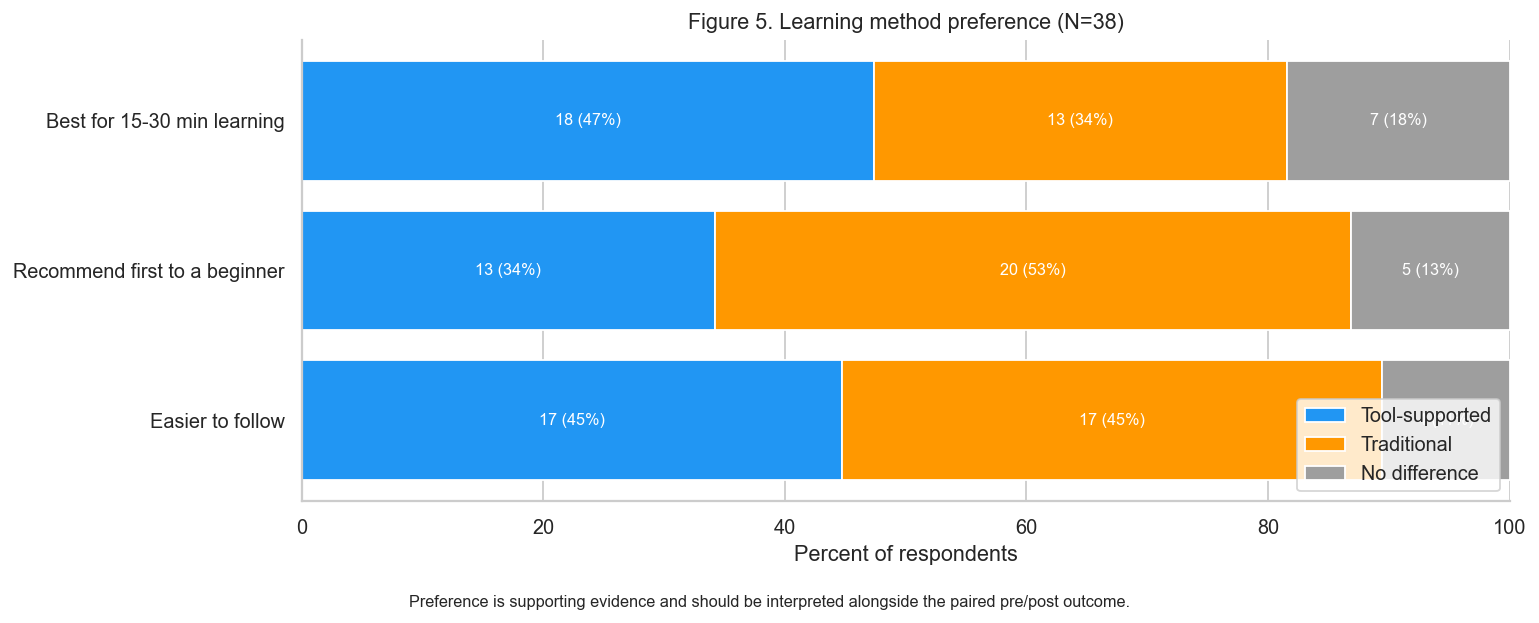

In [11]:
pref_display_names = {
    "pref_easier": "Easier to follow",
    "pref_beginner": "Recommend first to a beginner",
    "pref_quick": "Best for 15-30 min learning",
}

pref_pct = pd.DataFrame({
    pref_display_names[col]: df[col].value_counts(normalize=True).reindex(pref_order, fill_value=0) * 100
    for col in pref_cols
}).T
pref_counts = pd.DataFrame({
    pref_display_names[col]: df[col].value_counts().reindex(pref_order, fill_value=0)
    for col in pref_cols
}).T

fig, ax = plt.subplots(figsize=(12, 4.8))
left = np.zeros(len(pref_pct))
color_map = {
    pref_order[0]: TOOL_COLOR,
    pref_order[1]: TRAD_COLOR,
    pref_order[2]: NO_DIFF_COLOR,
}
for category in pref_order:
    values = pref_pct[category].to_numpy()
    bars = ax.barh(pref_pct.index, values, left=left, color=color_map[category], label=pref_short[category])
    counts = pref_counts[category].to_numpy()
    for bar, pct, count in zip(bars, values, counts):
        if pct >= 8:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
                    f"{count} ({pct:.0f}%)", ha="center", va="center", color="white", fontsize=9)
        else:
            ax.text(bar.get_x() + bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                    f"{count} ({pct:.0f}%)", ha="left", va="center", fontsize=9)
    left += values

ax.set_xlim(0, 100)
ax.set_xlabel("Percent of respondents")
ax.set_title(f"Figure 5. Learning method preference (N={len(df)})")
ax.legend(loc="lower right", frameon=True)
fig.text(0.5, 0.01, "Preference is supporting evidence and should be interpreted alongside the paired pre/post outcome.",
         ha="center", fontsize=9)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()


In [12]:
feature_table = pd.DataFrame(columns=["feature", "count", "percent"])


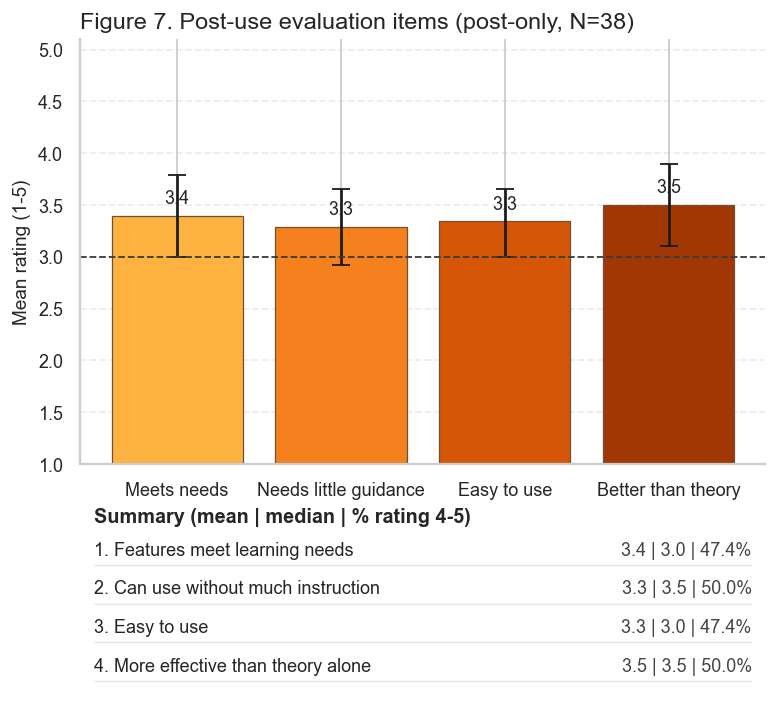

,Item,Mean,Median,% rating 4-5
0,Meets needs,3.4,3.0,47.4%
1,Needs little guidance,3.3,3.5,50.0%
2,Easy to use,3.3,3.0,47.4%
3,Better than theory,3.5,3.5,50.0%


In [13]:
tool_eval_labels = {
    "tool_eval_needs": "Features meet learning needs",
    "tool_eval_without_instruction": "Can use without much instruction",
    "tool_eval_easy_to_use": "Easy to use",
    "tool_eval_more_effective_than_theory": "More effective than theory alone",
}

tool_eval_short_labels = {
    "tool_eval_needs": "Meets needs",
    "tool_eval_without_instruction": "Needs little guidance",
    "tool_eval_easy_to_use": "Easy to use",
    "tool_eval_more_effective_than_theory": "Better than theory",
}

TOOL_EVAL_STYLE = {
    "figsize": (6.8, 6.6),
    "height_ratios": (3.1, 1.45),
    "bar_capsize": 5,
    "y_limits": (1.0, 5.1),
    "label_pad": 0.08,
    "grid_alpha": 0.35,
    "hspace": 0.12,
    "main_title_size": 13,
    "axis_label_size": 10.5,
    "tick_label_size": 10,
    "side_header_size": 11,
    "side_text_size": 10,
    "value_label_size": 10,
    "notes_wrap_width": 36,
}

def build_tool_eval_summary(df, tool_eval_cols, tool_eval_labels):
    rows = []
    for idx, col in enumerate(tool_eval_cols, start=1):
        mean_value, ci_low, ci_high = bootstrap_mean_ci(df[col], n_boot=2000, random_state=100 + idx)
        rows.append(
            {
                "item_key": col,
                "item_short": tool_eval_short_labels[col],
                "item_full": tool_eval_labels[col],
                "mean": mean_value,
                "median": float(df[col].median()),
                "ci_low": ci_low,
                "ci_high": ci_high,
                "pct_4_5": float(df[col].ge(4).mean() * 100),
            }
        )
    summary_df = pd.DataFrame(rows)
    summary_df["mean_fmt"] = summary_df["mean"].map(lambda v: f"{v:.1f}")
    summary_df["median_fmt"] = summary_df["median"].map(lambda v: f"{v:.1f}")
    summary_df["pct_4_5_fmt"] = summary_df["pct_4_5"].map(lambda v: f"{v:.1f}%")
    return summary_df

def plot_tool_eval_main(ax, summary_df, n):
    x = np.arange(len(summary_df))
    palette = sns.color_palette("YlOrBr", n_colors=len(summary_df) + 2)[2:]
    yerr = np.vstack(
        [
            summary_df["mean"] - summary_df["ci_low"],
            summary_df["ci_high"] - summary_df["mean"],
        ]
    )
    ax.bar(
        x,
        summary_df["mean"],
        yerr=yerr,
        capsize=TOOL_EVAL_STYLE["bar_capsize"],
        color=palette,
        edgecolor="#6F5135",
        linewidth=0.7,
    )
    ax.axhline(3, color="#3B3B3B", linestyle="--", linewidth=1)
    ax.set_ylim(*TOOL_EVAL_STYLE["y_limits"])
    ax.set_xticks(x)
    ax.set_xticklabels(summary_df["item_short"], rotation=0, ha="center", fontsize=TOOL_EVAL_STYLE["tick_label_size"])
    ax.tick_params(axis="y", labelsize=TOOL_EVAL_STYLE["tick_label_size"])
    ax.set_ylabel("Mean rating (1-5)", fontsize=TOOL_EVAL_STYLE["axis_label_size"])
    ax.set_title(
        f"Figure 7. Post-use evaluation items (post-only, N={n})",
        loc="left",
        fontsize=TOOL_EVAL_STYLE["main_title_size"],
    )
    ax.grid(axis="y", linestyle="--", alpha=TOOL_EVAL_STYLE["grid_alpha"])
    ax.set_axisbelow(True)
    for i, value in enumerate(summary_df["mean"]):
        ax.text(
            i,
            value + TOOL_EVAL_STYLE["label_pad"],
            f"{value:.1f}",
            ha="center",
            va="bottom",
            fontsize=TOOL_EVAL_STYLE["value_label_size"],
        )

def plot_tool_eval_notes(ax, summary_df):
    import textwrap

    ax.axis("off")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.text(
        0.02,
        0.97,
        "Summary (mean | median | % rating 4-5)",
        ha="left",
        va="top",
        fontsize=TOOL_EVAL_STYLE["side_header_size"],
        weight="bold",
    )

    start_y = 0.80
    row_gap = 0.195
    for idx, row in summary_df.iterrows():
        y = start_y - idx * row_gap
        label = textwrap.fill(f"{idx + 1}. {row['item_full']}", width=TOOL_EVAL_STYLE["notes_wrap_width"])
        metrics = f"{row['mean_fmt']} | {row['median_fmt']} | {row['pct_4_5_fmt']}"
        ax.text(0.02, y, label, ha="left", va="top", fontsize=TOOL_EVAL_STYLE["side_text_size"], linespacing=1.2)
        ax.text(
            0.98,
            y,
            metrics,
            ha="right",
            va="top",
            fontsize=TOOL_EVAL_STYLE["side_text_size"],
            color="#444444",
        )
        ax.hlines(y - 0.12, 0.02, 0.98, colors="#E6E6E6", linewidth=0.8)

def render_tool_eval_figure(summary_df, n):
    fig = plt.figure(figsize=TOOL_EVAL_STYLE["figsize"])
    gs = fig.add_gridspec(
        2,
        1,
        height_ratios=TOOL_EVAL_STYLE["height_ratios"],
        hspace=TOOL_EVAL_STYLE["hspace"],
    )
    ax_main = fig.add_subplot(gs[0, 0])
    ax_notes = fig.add_subplot(gs[1, 0])
    plot_tool_eval_main(ax_main, summary_df, n)
    plot_tool_eval_notes(ax_notes, summary_df)
    return fig

tool_eval_summary_df = build_tool_eval_summary(df, tool_eval_cols, tool_eval_labels)
fig = render_tool_eval_figure(tool_eval_summary_df, len(df))
plt.tight_layout()
plt.show()

tool_eval_summary_display = (
    tool_eval_summary_df[["item_short", "mean_fmt", "median_fmt", "pct_4_5_fmt"]]
    .rename(
        columns={
            "item_short": "Item",
            "mean_fmt": "Mean",
            "median_fmt": "Median",
            "pct_4_5_fmt": "% rating 4-5",
        }
    )
)
tool_eval_summary_display


## Appendix


In [14]:
sensitivity_rows = []
for label, frame in {
    "Full sample": df,
    "Exclude full straightliners": df.loc[~df["straightline_full12"]].copy(),
}.items():
    result = paired_wilcoxon_summary(frame["pre_composite"], frame["post_composite"])
    sensitivity_rows.append({
        "Sample": label,
        "N": len(frame),
        "Pre mean": frame["pre_composite"].mean(),
        "Post mean": frame["post_composite"].mean(),
        "Mean delta": frame["improvement"].mean(),
        "Wilcoxon p": result["p_raw"],
        "Rank-biserial": result["rank_biserial"],
    })

sensitivity_table = pd.DataFrame(sensitivity_rows)
display(
    sensitivity_table.style.format({
        "Pre mean": "{:.2f}",
        "Post mean": "{:.2f}",
        "Mean delta": "{:+.2f}",
        "Wilcoxon p": lambda v: format_p(v),
        "Rank-biserial": "{:+.3f}",
    })
)


,Sample,N,Pre mean,Post mean,Mean delta,Wilcoxon p,Rank-biserial
0,Full sample,38,3.14,3.30,+0.15,0.389,+0.197
1,Exclude full straightliners,30,3.18,3.38,+0.19,0.389,+0.197


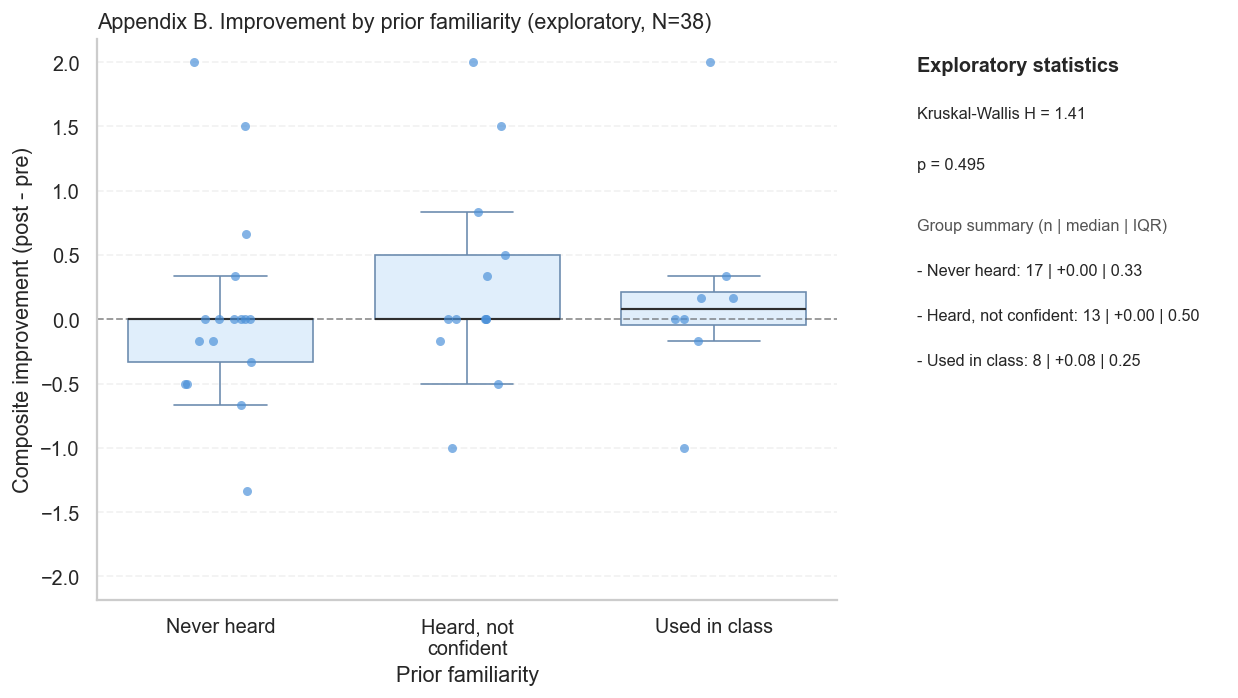

,Familiarity,n,Median,IQR
0,Never heard of them,17,+0.00,0.33
1,Heard of them but not confident,13,+0.00,0.50
2,Used in class before,8,+0.08,0.25


In [15]:
APPENDIX_B_STYLE = {
    "figsize": (11.2, 5.6),
    "width_ratios": (3.3, 1.4),
    "wspace": 0.14,
    "strip_size": 5,
    "strip_alpha": 0.68,
    "strip_jitter": 0.16,
    "box_color": "#DCEEFF",
    "baseline_color": "#4A4A4A",
    "baseline_alpha": 0.55,
    "main_title_size": 12,
    "side_title_size": 11,
    "side_text_size": 9,
    "grid_alpha": 0.25,
    "y_padding": 0.18,
}

def build_familiarity_payload(df, familiarity_order):
    groups = [df.loc[df["familiarity"] == level, "improvement"].dropna() for level in familiarity_order]
    group_counts = [int(len(group)) for group in groups]
    group_median = [float(group.median()) if len(group) > 0 else np.nan for group in groups]
    group_iqr = [
        float(group.quantile(0.75) - group.quantile(0.25)) if len(group) > 0 else np.nan
        for group in groups
    ]
    kw_available = all(len(group) > 0 for group in groups)
    kw_stat, kw_p = (np.nan, np.nan)
    if kw_available:
        kw_stat, kw_p = kruskal(*groups)

    payload = {
        "order": familiarity_order,
        "groups": groups,
        "group_counts": group_counts,
        "group_median": group_median,
        "group_iqr": group_iqr,
        "kw_available": bool(kw_available),
        "kw_stat": float(kw_stat) if kw_available else np.nan,
        "kw_p": float(kw_p) if kw_available else np.nan,
        "n": int(len(df)),
    }
    payload["summary_df"] = pd.DataFrame(
        {
            "Familiarity": payload["order"],
            "n": payload["group_counts"],
            "Median": payload["group_median"],
            "IQR": payload["group_iqr"],
        }
    )
    return payload

def plot_familiarity_main(ax, payload, style):
    short_labels = [
        "Never heard",
        "Heard, not\nconfident",
        "Used in class",
    ]
    sns.boxplot(
        data=df,
        x="familiarity",
        y="improvement",
        order=payload["order"],
        ax=ax,
        color=style["box_color"],
        showfliers=False,
        width=0.75,
        boxprops={"edgecolor": "#6B8BAE", "linewidth": 0.9},
        whiskerprops={"linewidth": 0.9, "color": "#6B8BAE"},
        capprops={"linewidth": 0.9, "color": "#6B8BAE"},
        medianprops={"color": "#2E2E2E", "linewidth": 1.2},
    )
    sns.stripplot(
        data=df,
        x="familiarity",
        y="improvement",
        order=payload["order"],
        ax=ax,
        color=PRE_COLOR,
        size=style["strip_size"],
        alpha=style["strip_alpha"],
        jitter=style["strip_jitter"],
    )

    ax.axhline(
        0,
        color=style["baseline_color"],
        linestyle="--",
        linewidth=1,
        alpha=style["baseline_alpha"],
    )
    ax.set_xlabel("Prior familiarity")
    ax.set_ylabel("Composite improvement (post - pre)")
    ax.set_title(
        f"Appendix B. Improvement by prior familiarity (exploratory, N={payload['n']})",
        loc="left",
        fontsize=style["main_title_size"],
    )
    ax.set_xticklabels(short_labels)
    ax.grid(axis="y", linestyle="--", alpha=style["grid_alpha"])
    ax.set_axisbelow(True)

    values = df["improvement"].dropna()
    if len(values) > 0:
        y_abs = max(abs(values.min()), abs(values.max()))
        y_lim = y_abs + style["y_padding"]
        ax.set_ylim(-y_lim, y_lim)

def plot_familiarity_side(ax, payload, style):
    ax.axis("off")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.text(
        0.02,
        0.97,
        "Exploratory statistics",
        ha="left",
        va="top",
        fontsize=style["side_title_size"],
        weight="bold",
    )

    if payload["kw_available"]:
        stats_lines = [
            f"Kruskal-Wallis H = {payload['kw_stat']:.2f}",
            f"p = {format_p(payload['kw_p'])}",
        ]
    else:
        stats_lines = [
            "Kruskal-Wallis: Not available",
            "(at least one group is empty)",
        ]

    y = 0.88
    for line in stats_lines:
        ax.text(0.02, y, line, ha="left", va="top", fontsize=style["side_text_size"])
        y -= 0.09

    y -= 0.02
    ax.text(0.02, y, "Group summary (n | median | IQR)", ha="left", va="top", fontsize=style["side_text_size"], color="#555555")
    y -= 0.08
    for level, n, med, iqr in zip(
        payload["order"],
        payload["group_counts"],
        payload["group_median"],
        payload["group_iqr"],
    ):
        med_txt = "-" if pd.isna(med) else f"{med:+.2f}"
        iqr_txt = "-" if pd.isna(iqr) else f"{iqr:.2f}"
        level_short = (
            "Never heard" if level == "Never heard of them" else
            "Heard, not confident" if level == "Heard of them but not confident" else
            "Used in class"
        )
        ax.text(
            0.02,
            y,
            f"- {level_short}: {n} | {med_txt} | {iqr_txt}",
            ha="left",
            va="top",
            fontsize=style["side_text_size"],
        )
        y -= 0.08

def render_familiarity_figure(payload, style, n):
    fig = plt.figure(figsize=style["figsize"])
    gs = fig.add_gridspec(1, 2, width_ratios=style["width_ratios"], wspace=style["wspace"])
    ax_main = fig.add_subplot(gs[0, 0])
    ax_side = fig.add_subplot(gs[0, 1])
    plot_familiarity_main(ax_main, payload, style)
    plot_familiarity_side(ax_side, payload, style)
    return fig

familiarity_payload = build_familiarity_payload(df, familiarity_order)
fig = render_familiarity_figure(familiarity_payload, APPENDIX_B_STYLE, len(df))
plt.tight_layout()
plt.show()

appendix_b_summary_table = familiarity_payload["summary_df"].copy()
appendix_b_summary_table["Median"] = appendix_b_summary_table["Median"].map(lambda v: "-" if pd.isna(v) else f"{v:+.2f}")
appendix_b_summary_table["IQR"] = appendix_b_summary_table["IQR"].map(lambda v: "-" if pd.isna(v) else f"{v:.2f}")
display(appendix_b_summary_table)


In [16]:
def overall_pattern_text(mean_delta, p_value, positive_items, negative_items):
    if pd.notna(p_value) and p_value < 0.05 and mean_delta >= 0.25:
        return "The overall pattern is a clear positive shift in self-reported understanding."
    if pd.notna(p_value) and p_value < 0.05 and mean_delta > 0:
        return "The overall pattern is a modest but detectable positive shift in self-reported understanding."
    if positive_items > 0 and negative_items > 0:
        return "The overall pattern is mixed across items, with some dimensions moving up and at least one moving down."
    return "The overall pattern shows little clear overall change in self-reported understanding."

def safe_question_label(item, question_labels):
    key = str(item).lower() if pd.notna(item) else ""
    return question_labels.get(key, "label unavailable")

item_delta_lookup = paired_descriptives.copy()
if {"Item", "Mean delta"}.issubset(item_delta_lookup.columns):
    item_delta_lookup = item_delta_lookup.set_index("Item")
    if "Composite" in item_delta_lookup.index:
        item_delta_lookup = item_delta_lookup.drop(index="Composite")
else:
    item_delta_lookup = pd.DataFrame(columns=["Mean delta"])

if len(item_delta_lookup) > 0:
    positive_item = str(item_delta_lookup["Mean delta"].idxmax())
    negative_item = str(item_delta_lookup["Mean delta"].idxmin())
    positive_value = float(item_delta_lookup.loc[positive_item, "Mean delta"])
    negative_value = float(item_delta_lookup.loc[negative_item, "Mean delta"])
    positive_items = int((item_delta_lookup["Mean delta"] > 0).sum())
    negative_items = int((item_delta_lookup["Mean delta"] < 0).sum())
else:
    positive_item, negative_item = "N/A", "N/A"
    positive_value, negative_value = np.nan, np.nan
    positive_items, negative_items = 0, 0

pref_majorities = []
for col in pref_cols:
    pretty_name = col.replace("pref_", "").replace("_", " ")
    counts = df[col].value_counts().reindex(pref_order, fill_value=0)
    if int(counts.sum()) == 0:
        pref_majorities.append(f"{pretty_name}: no valid responses")
    else:
        max_count = int(counts.max())
        winners = [idx for idx, value in counts.items() if int(value) == max_count]
        winner = winners[0]
        winner_label = pref_short.get(winner, str(winner))
        tie_note = " (tie)" if len(winners) > 1 else ""
        pref_majorities.append(f"{pretty_name}: {winner_label} ({max_count}/{len(df)}){tie_note}")

positive_label = safe_question_label(positive_item, question_labels)
negative_label = safe_question_label(negative_item, question_labels)
positive_value_text = "N/A" if pd.isna(positive_value) else f"{positive_value:+.2f}"
negative_value_text = "N/A" if pd.isna(negative_value) else f"{negative_value:+.2f}"

conclusion_md = f"""
## Final Findings

### 1) Core paired-learning outcome (primary result)
This analysis is based on **{report_label}**: only **Q1-Q6** are true paired pre-post items, while the composite is a derived summary metric.
The derived composite changed from **{df['pre_composite'].mean():.2f}** (pre) to **{df['post_composite'].mean():.2f}** (post), with mean delta **{df['improvement'].mean():+.2f}**.
Statistically, the paired Wilcoxon result is **p = {format_p(composite_result['p_raw'])}** with rank-biserial **{composite_result['rank_biserial']:+.3f}**.
At participant level, movement is heterogeneous: **improved/same/declined = {n_improved}/{n_same}/{n_declined}**.

### 2) Item-level interpretation (where change is and is not happening)
The strongest positive movement appears in **{positive_item} ({positive_label}) = {positive_value_text}**.
The weakest (or negative) movement appears in **{negative_item} ({negative_label}) = {negative_value_text}**.
Across all six paired items, **{positive_items}** moved upward and **{negative_items}** moved downward, indicating a mixed learning pattern across dimensions rather than uniform improvement.

### 3) Preference signals (supporting, not causal)
Learning preference is not one-dimensional; majority choices vary by context: **{'; '.join(pref_majorities)}**.

### 4) Interpretation guardrails
Post-use evaluation items are **post-only** and should be treated as supporting sentiment/usability evidence, not paired causal proof of learning gain.
This dataset contains **N={len(df)}** self-report responses, including **{int(df['straightline_full12'].sum())}** full straightliners across 12 repeated items, so subgroup findings remain exploratory.

## Actionable Takeaways

1. **Prioritize the weakest learning dimension first.**
Exact step: Use **{negative_item}** as the next design target; revise explanation flow, add clearer examples, and add one focused interaction (for example, a guided “why this step?” cue) tied to that concept.

2. **Preserve strengths in rapid orientation and guided exploration.**
Exact step: In the next iteration, keep the emphasis on short-session interpretive support and make quick-start guidance easier to access for novice users.

3. **Design for mixed learner needs, not one default path.**
Exact step: Ship two learning modes: a quick-start guided mode for lower familiarity users and a compact expert mode for experienced users.

4. **Set measurable targets for the next release.**
Exact step: Define success criteria before shipping: increase composite mean delta, reduce decline proportion, and remove negative shift in **{negative_item}**.

5. **Upgrade evaluation quality in the next survey cycle.**
Exact step: Add objective pre/post knowledge checks (short quiz), one attention check, and event tracking (time-on-task, feature interactions) to validate self-report findings.

6. **Run a focused follow-up experiment.**
Exact step: A/B test current vs improved insight flow on the weakest item and compare paired deltas with the same analysis pipeline.
"""

display(Markdown(conclusion_md))


## Final Findings

### 1) Core paired-learning outcome (primary result)
This analysis is based on **6 paired items + 1 derived composite**: only **Q1-Q6** are true paired pre-post items, while the composite is a derived summary metric.
The derived composite changed from **3.14** (pre) to **3.30** (post), with mean delta **+0.15**.
Statistically, the paired Wilcoxon result is **p = 0.389** with rank-biserial **+0.197**.
At participant level, movement is heterogeneous: **improved/same/declined = 13/13/12**.

### 2) Item-level interpretation (where change is and is not happening)
The strongest positive movement appears in **Q1 (Confidence in operation) = +0.29**.
The weakest (or negative) movement appears in **Q2 (Logic and math rules) = -0.08**.
Across all six paired items, **5** moved upward and **1** moved downward, indicating a mixed learning pattern across dimensions rather than uniform improvement.

### 3) Preference signals (supporting, not causal)
Learning preference is not one-dimensional; majority choices vary by context: **easier: Tool-supported (17/38) (tie); beginner: Traditional (20/38); quick: Tool-supported (18/38)**.

### 4) Interpretation guardrails
Post-use evaluation items are **post-only** and should be treated as supporting sentiment/usability evidence, not paired causal proof of learning gain.
This dataset contains **N=38** self-report responses, including **8** full straightliners across 12 repeated items, so subgroup findings remain exploratory.

## Actionable Takeaways

1. **Prioritize the weakest learning dimension first.**
Exact step: Use **Q2** as the next design target; revise explanation flow, add clearer examples, and add one focused interaction (for example, a guided “why this step?” cue) tied to that concept.

2. **Preserve strengths in rapid orientation and guided exploration.**
Exact step: In the next iteration, keep the emphasis on short-session interpretive support and make quick-start guidance easier to access for novice users.

3. **Design for mixed learner needs, not one default path.**
Exact step: Ship two learning modes: a quick-start guided mode for lower familiarity users and a compact expert mode for experienced users.

4. **Set measurable targets for the next release.**
Exact step: Define success criteria before shipping: increase composite mean delta, reduce decline proportion, and remove negative shift in **Q2**.

5. **Upgrade evaluation quality in the next survey cycle.**
Exact step: Add objective pre/post knowledge checks (short quiz), one attention check, and event tracking (time-on-task, feature interactions) to validate self-report findings.

6. **Run a focused follow-up experiment.**
Exact step: A/B test current vs improved insight flow on the weakest item and compare paired deltas with the same analysis pipeline.
